In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ============================================================
# Brain Tumor MRI Classification
# Report-aligned preprocessing methodology
#
# Uses:
# - Original Training folder for train/validation
# - Original Testing folder for final test
# - 224x224 resize
# - ImageNet normalization
# - Augmentation on training only
# ============================================================

import os
import random
import copy
import time
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score


# ======================
# Reproducibility
# ======================

seed = 101

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


# ======================
# Paths and labels
# ======================

DATA_DIR = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri"

labels = [
    "glioma_tumor",
    "no_tumor",
    "meningioma_tumor",
    "pituitary_tumor"
]

label_to_idx = {label: idx for idx, label in enumerate(labels)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

image_size = 224
batch_size = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ======================
# Load image paths only
# ======================

def collect_image_paths(split):
    image_paths = []
    image_labels = []

    for label in labels:
        folder_path = os.path.join(DATA_DIR, split, label)

        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            image_paths.append(img_path)
            image_labels.append(label_to_idx[label])

    return np.array(image_paths), np.array(image_labels)


trainval_paths, trainval_labels = collect_image_paths("Training")
test_paths, test_labels = collect_image_paths("Testing")

print("Original Training images:", len(trainval_paths))
print("Original Testing images:", len(test_paths))

print("\nTraining class distribution:")
for label in labels:
    print(label, np.sum(trainval_labels == label_to_idx[label]))

print("\nTesting class distribution:")
for label in labels:
    print(label, np.sum(test_labels == label_to_idx[label]))


# ======================
# Split original Training into train/val
# ======================

train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths,
    trainval_labels,
    test_size=0.10,
    random_state=seed,
    stratify=trainval_labels
)

print("\nFinal splits:")
print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))


# ======================
# Dataset class
# ======================

class BrainTumorPathDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label


# ======================
# Transforms
# ======================
# Report methodology:
# resize 224x224
# ImageNet normalization
# augmentation on training only:
# - horizontal flip
# - rotation ±15
# - zoom scale 0.85 to 1.15

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(
        size=image_size,
        scale=(0.85, 1.0)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ======================
# DataLoaders
# ======================

train_dataset = BrainTumorPathDataset(train_paths, train_labels, transform=train_transform)
val_dataset = BrainTumorPathDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = BrainTumorPathDataset(test_paths, test_labels, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Device: cuda
Original Training images: 2870
Original Testing images: 394

Training class distribution:
glioma_tumor 826
no_tumor 395
meningioma_tumor 822
pituitary_tumor 827

Testing class distribution:
glioma_tumor 100
no_tumor 105
meningioma_tumor 115
pituitary_tumor 74

Final splits:
Train: 2583
Validation: 287
Test: 394


In [4]:
# ============================================================
# Shared training and evaluation functions
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels_batch in loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    loss = running_loss / total
    acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return loss, acc, macro_f1, all_labels, all_preds


def print_test_results(model_name, y_true, y_pred, test_loss, test_acc, test_f1):
    print(f"\n{model_name} Test Results")
    print("-" * 45)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=labels,
        digits=4,
        zero_division=0
    ))

In [5]:
# ============================================================
# Model 1: CNN Baseline
# ============================================================

class CNNBaseline(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNBaseline, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 56 -> 28

            nn.AdaptiveAvgPool2d((7, 7))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


cnn = CNNBaseline(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn.parameters(),
    lr=1e-4
)

num_epochs = 30

best_val_f1 = 0.0
best_cnn_wts = copy.deepcopy(cnn.state_dict())

cnn_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        cnn, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        cnn, val_loader, criterion, device
    )

    cnn_history["train_loss"].append(train_loss)
    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_loss"].append(val_loss)
    cnn_history["val_acc"].append(val_acc)
    cnn_history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_cnn_wts = copy.deepcopy(cnn.state_dict())
        torch.save(cnn.state_dict(), "/kaggle/working/best_cnn_baseline.pth")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

cnn.load_state_dict(best_cnn_wts)

test_loss, test_acc, test_f1, y_true_cnn, y_pred_cnn = evaluate(
    cnn, test_loader, criterion, device
)

print_test_results(
    "CNN Baseline",
    y_true_cnn,
    y_pred_cnn,
    test_loss,
    test_acc,
    test_f1
)

cnn_results = pd.DataFrame([{
    "model": "CNN Baseline",
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1,
    "test_loss": test_loss
}])

cnn_results.to_csv("/kaggle/working/cnn_baseline_results.csv", index=False)
display(cnn_results)

Epoch [1/30] Train Acc: 0.5676 | Val Acc: 0.7282 | Val F1: 0.7311
Epoch [2/30] Train Acc: 0.6581 | Val Acc: 0.7213 | Val F1: 0.6897
Epoch [3/30] Train Acc: 0.6961 | Val Acc: 0.7352 | Val F1: 0.7264
Epoch [4/30] Train Acc: 0.7112 | Val Acc: 0.7770 | Val F1: 0.7809
Epoch [5/30] Train Acc: 0.7476 | Val Acc: 0.7491 | Val F1: 0.7466
Epoch [6/30] Train Acc: 0.7635 | Val Acc: 0.8084 | Val F1: 0.8065
Epoch [7/30] Train Acc: 0.7766 | Val Acc: 0.7840 | Val F1: 0.7735
Epoch [8/30] Train Acc: 0.7894 | Val Acc: 0.8188 | Val F1: 0.8097
Epoch [9/30] Train Acc: 0.8072 | Val Acc: 0.8432 | Val F1: 0.8452
Epoch [10/30] Train Acc: 0.8049 | Val Acc: 0.8606 | Val F1: 0.8588
Epoch [11/30] Train Acc: 0.8246 | Val Acc: 0.8746 | Val F1: 0.8738
Epoch [12/30] Train Acc: 0.8196 | Val Acc: 0.8711 | Val F1: 0.8728
Epoch [13/30] Train Acc: 0.8490 | Val Acc: 0.8537 | Val F1: 0.8507
Epoch [14/30] Train Acc: 0.8420 | Val Acc: 0.8606 | Val F1: 0.8578
Epoch [15/30] Train Acc: 0.8540 | Val Acc: 0.8397 | Val F1: 0.8376
Epoc

,model,test_accuracy,test_macro_f1,test_loss
0,CNN Baseline,0.553299,0.522152,2.415929


In [6]:
# ============================================================
# Model 2: EfficientNet-B0 Dense
# Two-phase fine-tuning
# ============================================================

def create_efficientnet_b0(num_classes=4):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model


effnet = create_efficientnet_b0(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()


# ======================
# Phase 1: freeze feature extractor, train classifier head
# ======================

for param in effnet.features.parameters():
    param.requires_grad = False

for param in effnet.classifier.parameters():
    param.requires_grad = True

phase1_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-3,
    weight_decay=1e-2
)

phase1_epochs = 5

print("\nPhase 1: Training classifier head only")
print("-------------------------------------")

for epoch in range(phase1_epochs):
    train_loss, train_acc = train_one_epoch(
        effnet, train_loader, criterion, phase1_optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        effnet, val_loader, criterion, device
    )

    print(
        f"Phase 1 Epoch [{epoch+1}/{phase1_epochs}] "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )


# ======================
# Phase 2: unfreeze top 20 layers
# ======================

for param in effnet.features.parameters():
    param.requires_grad = False

# EfficientNet features is a Sequential block.
# Unfreeze last 20 child modules from features.
feature_children = list(effnet.features.children())

# More practical interpretation:
# unfreeze the later EfficientNet blocks rather than literal individual layers.
# This usually corresponds to the high-level top layers.
for child in feature_children[-3:]:
    for param in child.parameters():
        param.requires_grad = True

for param in effnet.classifier.parameters():
    param.requires_grad = True

phase2_epochs = 20

phase2_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, effnet.parameters()),
    lr=1e-4,
    weight_decay=1e-2
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    phase2_optimizer,
    T_max=phase2_epochs
)

best_val_f1 = 0.0
best_effnet_wts = copy.deepcopy(effnet.state_dict())

effnet_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

print("\nPhase 2: Fine-tuning top EfficientNet layers")
print("--------------------------------------------")

for epoch in range(phase2_epochs):
    train_loss, train_acc = train_one_epoch(
        effnet, train_loader, criterion, phase2_optimizer, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        effnet, val_loader, criterion, device
    )

    scheduler.step()

    effnet_history["train_loss"].append(train_loss)
    effnet_history["train_acc"].append(train_acc)
    effnet_history["val_loss"].append(val_loss)
    effnet_history["val_acc"].append(val_acc)
    effnet_history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_effnet_wts = copy.deepcopy(effnet.state_dict())
        torch.save(effnet.state_dict(), "/kaggle/working/best_efficientnet_b0.pth")

    print(
        f"Phase 2 Epoch [{epoch+1}/{phase2_epochs}] "
        f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
    )

effnet.load_state_dict(best_effnet_wts)

test_loss, test_acc, test_f1, y_true_effnet, y_pred_effnet = evaluate(
    effnet, test_loader, criterion, device
)

print_test_results(
    "EfficientNet-B0 Dense",
    y_true_effnet,
    y_pred_effnet,
    test_loss,
    test_acc,
    test_f1
)

effnet_results = pd.DataFrame([{
    "model": "EfficientNet-B0 Dense",
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1,
    "test_loss": test_loss
}])

effnet_results.to_csv("/kaggle/working/efficientnet_b0_dense_results.csv", index=False)
display(effnet_results)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 216MB/s]


Phase 1: Training classifier head only
-------------------------------------


Phase 1 Epoch [1/5] Train Acc: 0.6531 | Val Acc: 0.8258 | Val F1: 0.8159
Phase 1 Epoch [2/5] Train Acc: 0.7696 | Val Acc: 0.8328 | Val F1: 0.8266
Phase 1 Epoch [3/5] Train Acc: 0.7793 | Val Acc: 0.8258 | Val F1: 0.8194
Phase 1 Epoch [4/5] Train Acc: 0.8014 | Val Acc: 0.8153 | Val F1: 0.8091
Phase 1 Epoch [5/5] Train Acc: 0.8080 | Val Acc: 0.8258 | Val F1: 0.8224

Phase 2: Fine-tuning top EfficientNet layers
--------------------------------------------
Phase 2 Epoch [1/20] Train Acc: 0.8355 | Val Acc: 0.8955 | Val F1: 0.8917
Phase 2 Epoch [2/20] Train Acc: 0.8800 | Val Acc: 0.9059 | Val F1: 0.9058
Phase 2 Epoch [3/20] Train Acc: 0.9082 | Val Acc: 0.9268 | Val F1: 0.9314
Phase 2 Epoch [4/20] Train Acc: 0.9299 | Val Acc: 0.9443 | Val F1: 0.9483
Phase 2 Epoch [5/20] Train Acc: 0.9295 | Val Acc: 0.9408 | Val F1: 0.9450
Phase 2 Epoch [6/20] Train Acc: 0.9493 | Val Acc: 0.9512 | Val F1: 0.9525
Phase 2 Epoch [7/20] Train Acc: 0.9555 | Val Acc: 0.9443 | Val F1: 0.9483
Phase 2 Epoch [8/20] Train

,model,test_accuracy,test_macro_f1,test_loss
0,EfficientNet-B0 Dense,0.779188,0.757618,1.30117


Device: cuda

Dense EfficientNet-B0 Baseline
------------------------------
Test Accuracy: 0.7792
Test Macro F1: 0.7576
Total Sparsity: 0.0000
Conv Sparsity: 0.0000
Model Size: 15.60 MB
Compressed Size: 14.39 MB
Inference Time: 1.0823 ms/image

Structured pruning EfficientNet-B0 at 20%
Pruned 81 Conv2d layers at 20%
Initial Total Sparsity: 0.0000
Initial Conv Sparsity: 0.1999
Epoch [1/10] Train Loss: 0.4469 | Train Acc: 0.8366 Val Loss: 0.2006 | Val Acc: 0.9303 | Val F1: 0.9305
Epoch [2/10] Train Loss: 0.2619 | Train Acc: 0.9044 Val Loss: 0.1706 | Val Acc: 0.9303 | Val F1: 0.9377
Epoch [3/10] Train Loss: 0.2052 | Train Acc: 0.9257 Val Loss: 0.1265 | Val Acc: 0.9547 | Val F1: 0.9589
Epoch [4/10] Train Loss: 0.1665 | Train Acc: 0.9412 Val Loss: 0.0886 | Val Acc: 0.9791 | Val F1: 0.9802
Epoch [5/10] Train Loss: 0.1405 | Train Acc: 0.9512 Val Loss: 0.0946 | Val Acc: 0.9686 | Val F1: 0.9711
Epoch [6/10] Train Loss: 0.1215 | Train Acc: 0.9590 Val Loss: 0.0974 | Val Acc: 0.9756 | Val F1: 0.97

,model,target_pruning,total_sparsity,conv_sparsity,test_accuracy,test_macro_f1,test_loss,model_size_mb,compressed_size_mb,inference_time_ms_per_image,zero_params,total_params,conv_zero_params,conv_total_params
0,EfficientNet-B0 Dense,0.0,0.000000,0.000000,0.779188,0.757618,1.301170,15.596606,14.393549,1.082252,0,4012672,0,3956192
1,EfficientNet-B0 Pruned 20%,0.2,0.197101,0.199915,0.730964,0.687802,1.277178,15.598247,11.859552,1.124554,790903,4012672,790903,3956192
2,EfficientNet-B0 Pruned 40%,0.4,0.394422,0.400053,0.535533,0.518503,1.488906,15.598247,9.270307,1.118610,1582685,4012672,1582685,3956192
3,EfficientNet-B0 Pruned 60%,0.6,0.591503,0.599947,0.428934,0.392266,1.799552,15.598247,6.658600,1.082981,2373507,4012672,2373507,3956192
4,EfficientNet-B0 Pruned 80%,0.8,0.788823,0.800085,0.253807,0.101215,1.432905,15.598247,4.011248,1.204812,3165289,4012672,3165289,3956192



Saved to:
/kaggle/working/efficientnet_b0_report_method_pruning_results.csv


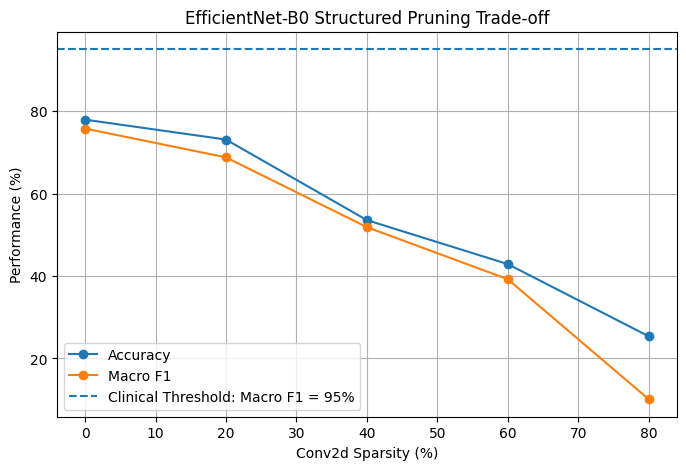

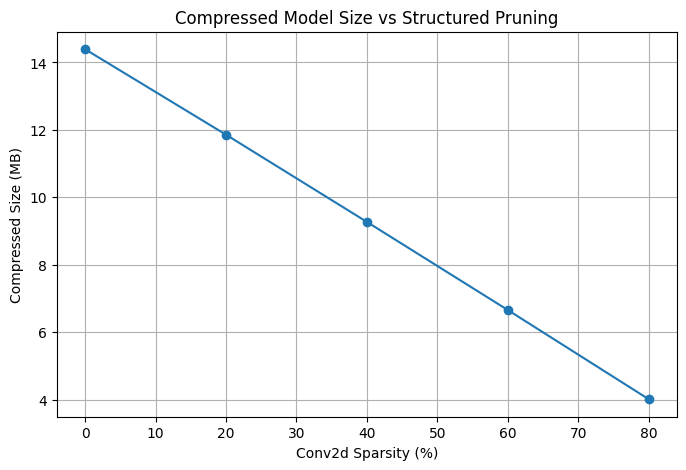

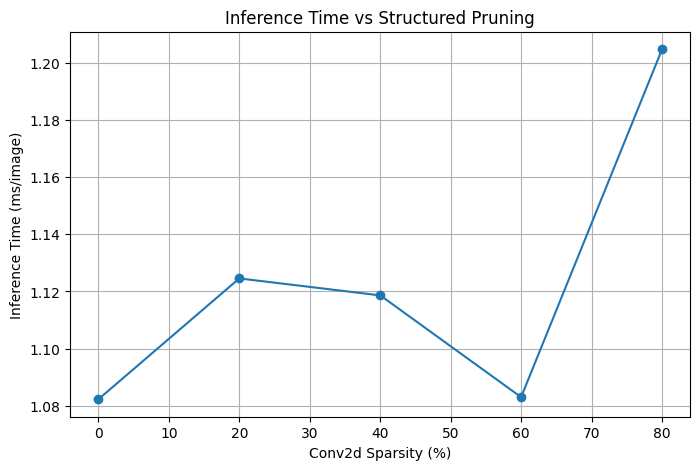


Clinically Viable Models
------------------------


,model,target_pruning,total_sparsity,conv_sparsity,test_accuracy,test_macro_f1,test_loss,model_size_mb,compressed_size_mb,inference_time_ms_per_image,zero_params,total_params,conv_zero_params,conv_total_params


No model met the clinical viability threshold of Macro F1 >= 0.95.


In [7]:
# ============================================================
# Model 3: Structured Weight Pruning
# Report methodology implementation AS SUBMITTED
#
# - L1-norm structured pruning
# - Apply to all Conv2d layers
# - Sparsity levels: 20%, 40%, 60%, 80%
# - Fine-tune each pruned model for 10 epochs
# - Evaluate accuracy, macro F1, model size, inference time
# ============================================================

import os
import copy
import time
import gzip
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import torchvision.models as models

from sklearn.metrics import classification_report, confusion_matrix, f1_score


# ======================
# 1. Settings
# ======================

num_classes = 4
pruning_levels = [0.20, 0.40, 0.60, 0.80]
fine_tune_epochs = 10

dense_model_path = "/kaggle/working/best_efficientnet_b0.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ======================
# 2. Create EfficientNet-B0
# Must match your dense model exactly
# ======================

def create_efficientnet_b0(num_classes=4):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = models.efficientnet_b0(weights=weights)

    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )

    return model


# ======================
# 3. Report-style structured pruning
# ======================

def apply_report_structured_pruning(model, amount):
    """
    Applies L1-norm structured pruning to every Conv2d layer.

    This follows the submitted report methodology:
    - For each convolutional layer
    - Rank filters by L1 norm
    - Prune bottom s%
    - Use torch.nn.utils.prune.ln_structured
    """

    pruned_layers = []

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(
                module,
                name="weight",
                amount=amount,
                n=1,
                dim=0
            )
            pruned_layers.append(name)

    print(f"Pruned {len(pruned_layers)} Conv2d layers at {int(amount * 100)}%")
    return model, pruned_layers


def remove_pruning_reparameterization(model):
    """
    Makes pruning permanent after fine-tuning.
    Keeps the zeroed filters zero.
    """

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            try:
                prune.remove(module, "weight")
            except ValueError:
                pass

    return model


# ======================
# 4. Sparsity calculations
# ======================

def calculate_total_sparsity(model):
    total_params = 0
    zero_params = 0

    for param in model.parameters():
        total_params += param.numel()
        zero_params += torch.sum(param == 0).item()

    sparsity = zero_params / total_params if total_params > 0 else 0
    return sparsity, zero_params, total_params


def calculate_conv_sparsity(model):
    total_params = 0
    zero_params = 0

    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            weight = module.weight
            total_params += weight.numel()
            zero_params += torch.sum(weight == 0).item()

    sparsity = zero_params / total_params if total_params > 0 else 0
    return sparsity, zero_params, total_params


# ======================
# 5. Model size
# ======================

def get_model_size_mb(model, filename):
    torch.save(model.state_dict(), filename)
    return os.path.getsize(filename) / (1024 * 1024)


def get_compressed_model_size_mb(model, filename):
    state_dict = model.state_dict()

    with gzip.open(filename, "wb") as f:
        pickle.dump(state_dict, f)

    return os.path.getsize(filename) / (1024 * 1024)


# ======================
# 6. Inference time
# ======================

def measure_inference_time(model, loader, device, num_batches=20):
    model.eval()

    times = []
    total_images = 0

    # Warm-up
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(loader):
            if batch_idx >= 3:
                break

            images = images.to(device)
            _ = model(images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    # Timed inference
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(loader):
            if batch_idx >= num_batches:
                break

            images = images.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start_time = time.time()
            _ = model(images)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end_time = time.time()

            times.append(end_time - start_time)
            total_images += images.size(0)

    return (sum(times) / total_images) * 1000


# ======================
# 7. Training and evaluation
# ======================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels_batch in loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels_batch).sum().item()
        total += labels_batch.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels_batch)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels_batch).sum().item()
            total += labels_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    loss = running_loss / total
    acc = correct / total
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return loss, acc, macro_f1, all_labels, all_preds


# ======================
# 8. Dense baseline evaluation
# ======================

criterion = nn.CrossEntropyLoss()

dense_model = create_efficientnet_b0(num_classes=num_classes)
dense_model.load_state_dict(torch.load(dense_model_path, map_location=device))
dense_model = dense_model.to(device)

dense_test_loss, dense_test_acc, dense_test_f1, _, _ = evaluate(
    dense_model,
    test_loader,
    criterion,
    device
)

dense_total_sparsity, dense_zero_params, dense_total_params = calculate_total_sparsity(dense_model)
dense_conv_sparsity, dense_conv_zero_params, dense_conv_total_params = calculate_conv_sparsity(dense_model)

dense_model_size = get_model_size_mb(
    dense_model,
    "/kaggle/working/dense_efficientnet_b0.pth"
)

dense_compressed_size = get_compressed_model_size_mb(
    dense_model,
    "/kaggle/working/dense_efficientnet_b0.pkl.gz"
)

dense_inference_time = measure_inference_time(
    dense_model,
    test_loader,
    device
)

print("\nDense EfficientNet-B0 Baseline")
print("------------------------------")
print(f"Test Accuracy: {dense_test_acc:.4f}")
print(f"Test Macro F1: {dense_test_f1:.4f}")
print(f"Total Sparsity: {dense_total_sparsity:.4f}")
print(f"Conv Sparsity: {dense_conv_sparsity:.4f}")
print(f"Model Size: {dense_model_size:.2f} MB")
print(f"Compressed Size: {dense_compressed_size:.2f} MB")
print(f"Inference Time: {dense_inference_time:.4f} ms/image")


# ======================
# 9. Pruning experiment
# ======================

pruning_results = []

pruning_results.append({
    "model": "EfficientNet-B0 Dense",
    "target_pruning": 0.00,
    "total_sparsity": dense_total_sparsity,
    "conv_sparsity": dense_conv_sparsity,
    "test_accuracy": dense_test_acc,
    "test_macro_f1": dense_test_f1,
    "test_loss": dense_test_loss,
    "model_size_mb": dense_model_size,
    "compressed_size_mb": dense_compressed_size,
    "inference_time_ms_per_image": dense_inference_time,
    "zero_params": dense_zero_params,
    "total_params": dense_total_params,
    "conv_zero_params": dense_conv_zero_params,
    "conv_total_params": dense_conv_total_params
})


for amount in pruning_levels:
    print("\n" + "=" * 70)
    print(f"Structured pruning EfficientNet-B0 at {int(amount * 100)}%")
    print("=" * 70)

    # Load fresh dense model each time
    pruned_model = create_efficientnet_b0(num_classes=num_classes)
    pruned_model.load_state_dict(torch.load(dense_model_path, map_location=device))
    pruned_model = pruned_model.to(device)

    # Apply report-style pruning to all Conv2d layers
    pruned_model, pruned_layers = apply_report_structured_pruning(
        pruned_model,
        amount=amount
    )

    initial_total_sparsity, _, _ = calculate_total_sparsity(pruned_model)
    initial_conv_sparsity, _, _ = calculate_conv_sparsity(pruned_model)

    print(f"Initial Total Sparsity: {initial_total_sparsity:.4f}")
    print(f"Initial Conv Sparsity: {initial_conv_sparsity:.4f}")

    # Fine-tune for 10 epochs, as report states
    optimizer = optim.AdamW(
        pruned_model.parameters(),
        lr=1e-4,
        weight_decay=1e-2
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=fine_tune_epochs
    )

    best_val_f1 = 0.0
    best_model_wts = copy.deepcopy(pruned_model.state_dict())

    for epoch in range(fine_tune_epochs):
        train_loss, train_acc = train_one_epoch(
            pruned_model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate(
            pruned_model,
            val_loader,
            criterion,
            device
        )

        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_wts = copy.deepcopy(pruned_model.state_dict())

        print(
            f"Epoch [{epoch+1}/{fine_tune_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
        )

    # Load best masked model
    pruned_model.load_state_dict(best_model_wts)

    # Make pruning permanent after fine-tuning
    pruned_model = remove_pruning_reparameterization(pruned_model)

    final_total_sparsity, zero_params, total_params = calculate_total_sparsity(pruned_model)
    final_conv_sparsity, conv_zero_params, conv_total_params = calculate_conv_sparsity(pruned_model)

    print(f"\nFinal Total Sparsity: {final_total_sparsity:.4f}")
    print(f"Final Conv Sparsity: {final_conv_sparsity:.4f}")

    # Test evaluation
    test_loss, test_acc, test_f1, y_true_pruned, y_pred_pruned = evaluate(
        pruned_model,
        test_loader,
        criterion,
        device
    )

    model_filename = f"/kaggle/working/efficientnet_b0_pruned_{int(amount * 100)}.pth"
    compressed_filename = f"/kaggle/working/efficientnet_b0_pruned_{int(amount * 100)}.pkl.gz"

    model_size = get_model_size_mb(pruned_model, model_filename)
    compressed_size = get_compressed_model_size_mb(pruned_model, compressed_filename)

    inference_time = measure_inference_time(
        pruned_model,
        test_loader,
        device
    )

    print("\nPruned Model Test Results")
    print("-------------------------")
    print(f"Target Pruning: {int(amount * 100)}%")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Macro F1: {test_f1:.4f}")
    print(f"Total Sparsity: {final_total_sparsity:.4f}")
    print(f"Conv Sparsity: {final_conv_sparsity:.4f}")
    print(f"Model Size: {model_size:.2f} MB")
    print(f"Compressed Size: {compressed_size:.2f} MB")
    print(f"Inference Time: {inference_time:.4f} ms/image")

    print("\nClassification Report:")
    print(classification_report(
        y_true_pruned,
        y_pred_pruned,
        target_names=labels,
        digits=4,
        zero_division=0
    ))

    pruning_results.append({
        "model": f"EfficientNet-B0 Pruned {int(amount * 100)}%",
        "target_pruning": amount,
        "total_sparsity": final_total_sparsity,
        "conv_sparsity": final_conv_sparsity,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1,
        "test_loss": test_loss,
        "model_size_mb": model_size,
        "compressed_size_mb": compressed_size,
        "inference_time_ms_per_image": inference_time,
        "zero_params": zero_params,
        "total_params": total_params,
        "conv_zero_params": conv_zero_params,
        "conv_total_params": conv_total_params
    })


# ======================
# 10. Save results
# ======================

pruning_df = pd.DataFrame(pruning_results)

pruning_df.to_csv(
    "/kaggle/working/efficientnet_b0_report_method_pruning_results.csv",
    index=False
)

print("\nFinal Report-Method Pruning Results")
print("-----------------------------------")
display(pruning_df)

print("\nSaved to:")
print("/kaggle/working/efficientnet_b0_report_method_pruning_results.csv")


# ======================
# 11. Plot compression-performance curve
# ======================

plt.figure(figsize=(8, 5))
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["test_accuracy"] * 100,
    marker="o",
    label="Accuracy"
)
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["test_macro_f1"] * 100,
    marker="o",
    label="Macro F1"
)
plt.axhline(y=95, linestyle="--", label="Clinical Threshold: Macro F1 = 95%")
plt.xlabel("Conv2d Sparsity (%)")
plt.ylabel("Performance (%)")
plt.title("EfficientNet-B0 Structured Pruning Trade-off")
plt.legend()
plt.grid(True)
plt.show()


# ======================
# 12. Plot compressed size
# ======================

plt.figure(figsize=(8, 5))
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["compressed_size_mb"],
    marker="o"
)
plt.xlabel("Conv2d Sparsity (%)")
plt.ylabel("Compressed Size (MB)")
plt.title("Compressed Model Size vs Structured Pruning")
plt.grid(True)
plt.show()


# ======================
# 13. Plot inference time
# ======================

plt.figure(figsize=(8, 5))
plt.plot(
    pruning_df["conv_sparsity"] * 100,
    pruning_df["inference_time_ms_per_image"],
    marker="o"
)
plt.xlabel("Conv2d Sparsity (%)")
plt.ylabel("Inference Time (ms/image)")
plt.title("Inference Time vs Structured Pruning")
plt.grid(True)
plt.show()


# ======================
# 14. Clinical viability check
# ======================

clinical_threshold = 0.95

viable_models = pruning_df[pruning_df["test_macro_f1"] >= clinical_threshold]

print("\nClinically Viable Models")
print("------------------------")
display(viable_models)

if len(viable_models) > 0:
    best_compressed = viable_models.sort_values(
        by="conv_sparsity",
        ascending=False
    ).iloc[0]

    print("\nMaximum Clinically Viable Compression")
    print("-------------------------------------")
    print(f"Model: {best_compressed['model']}")
    print(f"Target Pruning: {best_compressed['target_pruning'] * 100:.0f}%")
    print(f"Conv Sparsity: {best_compressed['conv_sparsity'] * 100:.2f}%")
    print(f"Total Sparsity: {best_compressed['total_sparsity'] * 100:.2f}%")
    print(f"Test Accuracy: {best_compressed['test_accuracy'] * 100:.2f}%")
    print(f"Test Macro F1: {best_compressed['test_macro_f1'] * 100:.2f}%")
    print(f"Compressed Size: {best_compressed['compressed_size_mb']:.2f} MB")
    print(f"Inference Time: {best_compressed['inference_time_ms_per_image']:.4f} ms/image")
else:
    print("No model met the clinical viability threshold of Macro F1 >= 0.95.")